<a href="https://colab.research.google.com/github/karthik0907/Predicting-Income-Level-Using-Demographic-and-Employment-Data-with-Machine-Learning/blob/main/karthik_full_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# pandas and numpy for preprocessing
import pandas as pd
import numpy as np


In [4]:
# Load your CSV file
df = pd.read_csv("adult.csv")

# See first 5 rows
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
# Shape of dataset (rows, columns)
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types and non-null counts
df.info()


Shape: (32561, 15)

Columns:
 Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  

In [6]:
# Remove spaces and replace '.' with '_'
df.columns = df.columns.str.strip().str.replace(".", "_", regex=False)

# Check updated column names
df.columns


Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [7]:
# Select all categorical columns
cat_cols = df.select_dtypes(include="object").columns

# Remove leading and trailing spaces
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.strip())

df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [8]:
# Replace ? with NaN (actual missing value)
df = df.replace("?", np.nan)

# Check missing values
df.isnull().sum()


,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [9]:
# Remove rows containing any missing value
df = df.dropna()

# Reset index after dropping rows
df = df.reset_index(drop=True)

print("New Shape:", df.shape)


New Shape: (30162, 15)


In [10]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)


Duplicate rows: 23
After removing duplicates: (30139, 15)


In [11]:
# Clean income column
df["income"] = df["income"].str.strip()

# Unique values
df["income"].unique()


array(['<=50K', '>50K'], dtype=object)

In [12]:
# Final dataset overview
df.info()

# Check missing values again
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30139 entries, 0 to 30138
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30139 non-null  int64 
 1   workclass       30139 non-null  object
 2   fnlwgt          30139 non-null  int64 
 3   education       30139 non-null  object
 4   education_num   30139 non-null  int64 
 5   marital_status  30139 non-null  object
 6   occupation      30139 non-null  object
 7   relationship    30139 non-null  object
 8   race            30139 non-null  object
 9   sex             30139 non-null  object
 10  capital_gain    30139 non-null  int64 
 11  capital_loss    30139 non-null  int64 
 12  hours_per_week  30139 non-null  int64 
 13  native_country  30139 non-null  object
 14  income          30139 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.4+ MB


,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [13]:

#  Descriptive stats

# Numerical descriptive statistics
print("NUMERICAL DESCRIPTIVE STATS")
display(df.describe())

# Categorical descriptive statistics
print("\nCATEGORICAL DESCRIPTIVE STATS")
display(df.describe(include="object"))


NUMERICAL DESCRIPTIVE STATS


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,30139.000000,3.013900e+04,30139.000000,30139.000000,30139.000000,30139.000000
mean,38.441720,1.897950e+05,10.122532,1092.841202,88.439928,40.934703
std,13.131426,1.056586e+05,2.548738,7409.110596,404.445239,11.978753
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176275e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784170e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376045e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



CATEGORICAL DESCRIPTIVE STATS


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,30139,30139,30139,30139,30139,30139,30139,30139,30139
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22264,9834,14059,4034,12457,25912,20366,27487,22633


income
<=50K    22633
>50K      7506
Name: count, dtype: int64


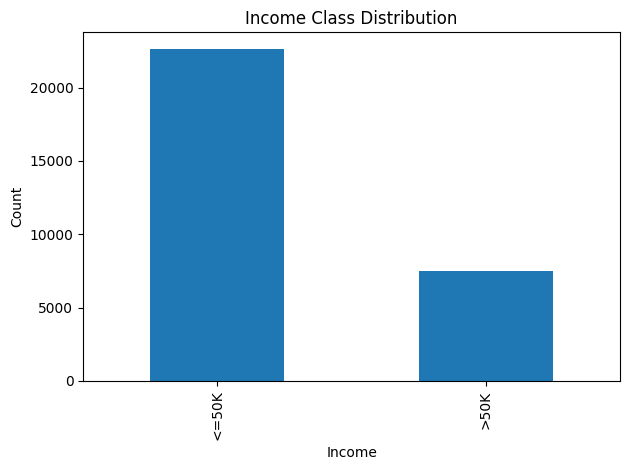

In [14]:

#  Target distribution (income)
import matplotlib.pyplot as plt

income_counts = df["income"].value_counts()
print(income_counts)

plt.figure()
income_counts.plot(kind="bar")
plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


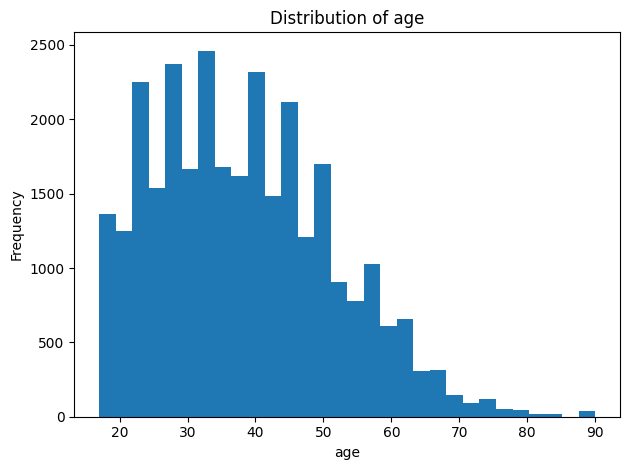

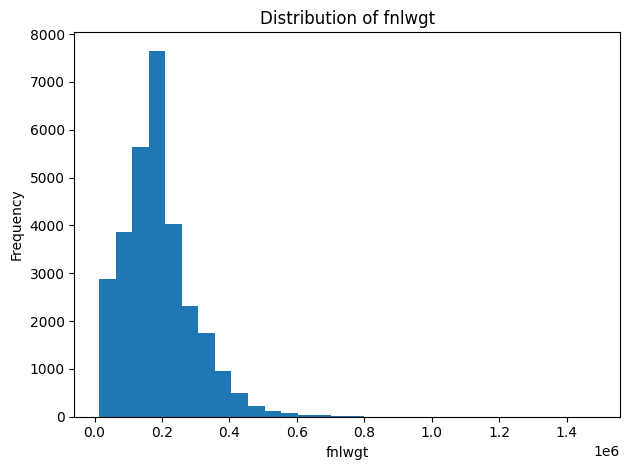

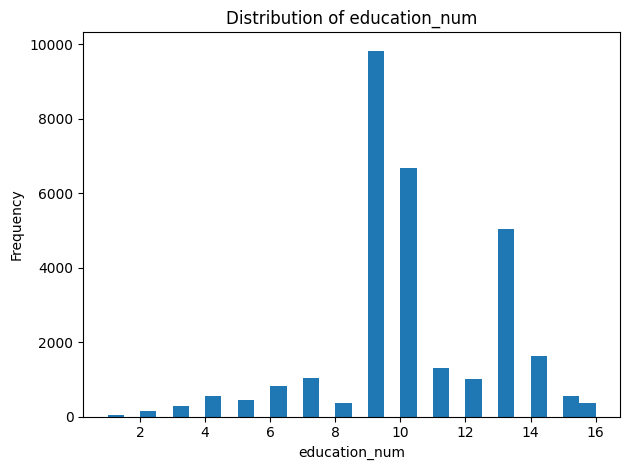

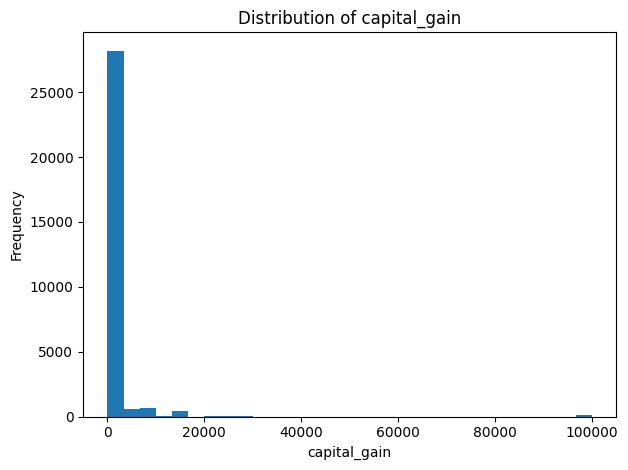

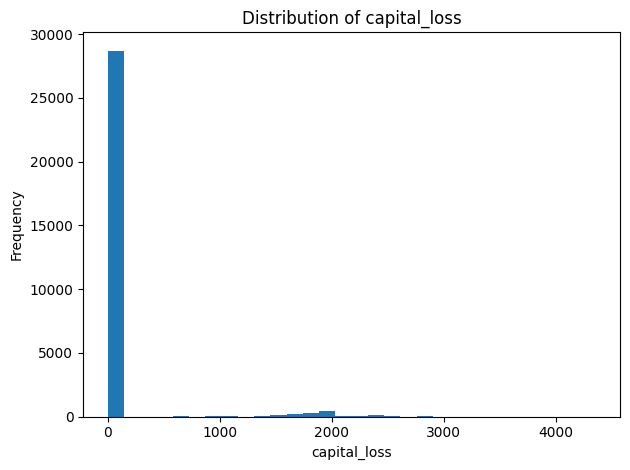

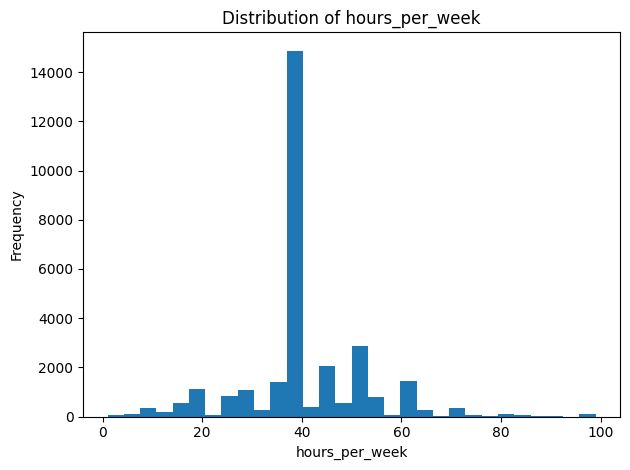

In [15]:

#  Numerical distributions (histograms)

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    df[col].plot(kind="hist", bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


<Figure size 640x480 with 0 Axes>

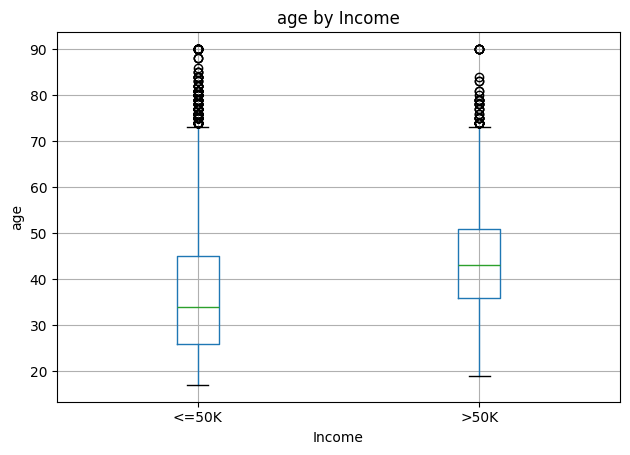

<Figure size 640x480 with 0 Axes>

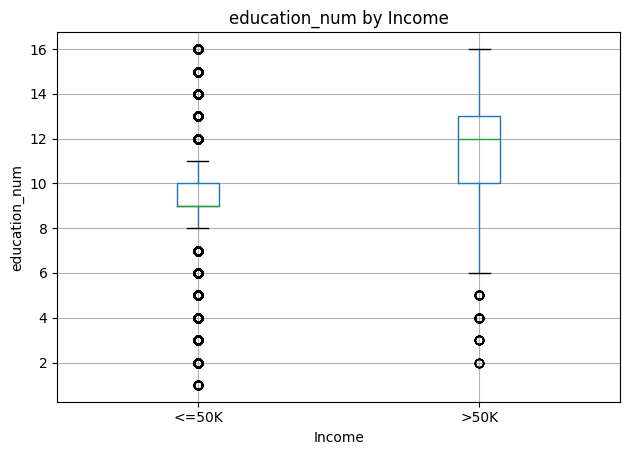

<Figure size 640x480 with 0 Axes>

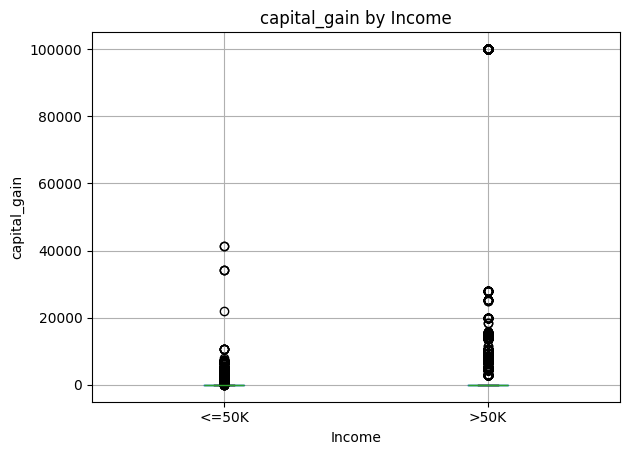

<Figure size 640x480 with 0 Axes>

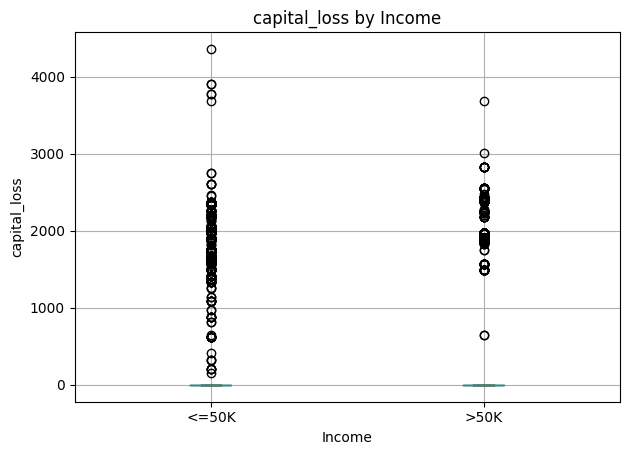

<Figure size 640x480 with 0 Axes>

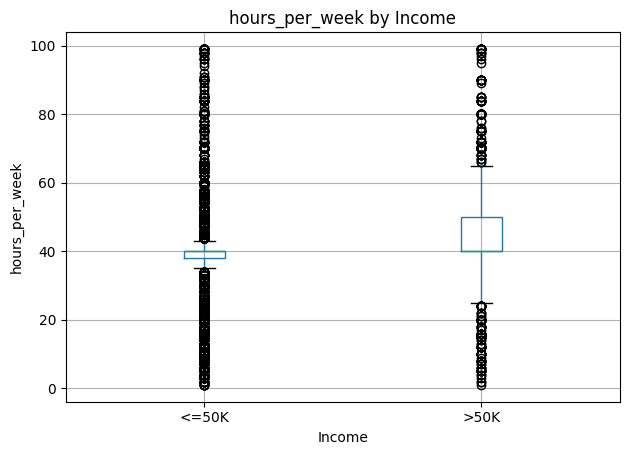

In [16]:

# Compare numerical features by income (boxplots)

# Helps see how age/hours/capital differ for <=50K vs >50K

num_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

for col in num_cols:
    plt.figure()
    df.boxplot(column=col, by="income")
    plt.title(f"{col} by Income")
    plt.suptitle("")  # remove default extra title
    plt.xlabel("Income")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.076279,0.043203,0.080162,0.060141,0.101348
fnlwgt,-0.076279,1.000000,-0.045199,0.000420,-0.009755,-0.023033
education_num,0.043203,-0.045199,1.000000,0.124455,0.079613,0.152842
capital_gain,0.080162,0.000420,0.124455,1.000000,-0.032255,0.080429
capital_loss,0.060141,-0.009755,0.079613,-0.032255,1.000000,0.052380
hours_per_week,0.101348,-0.023033,0.152842,0.080429,0.052380,1.000000


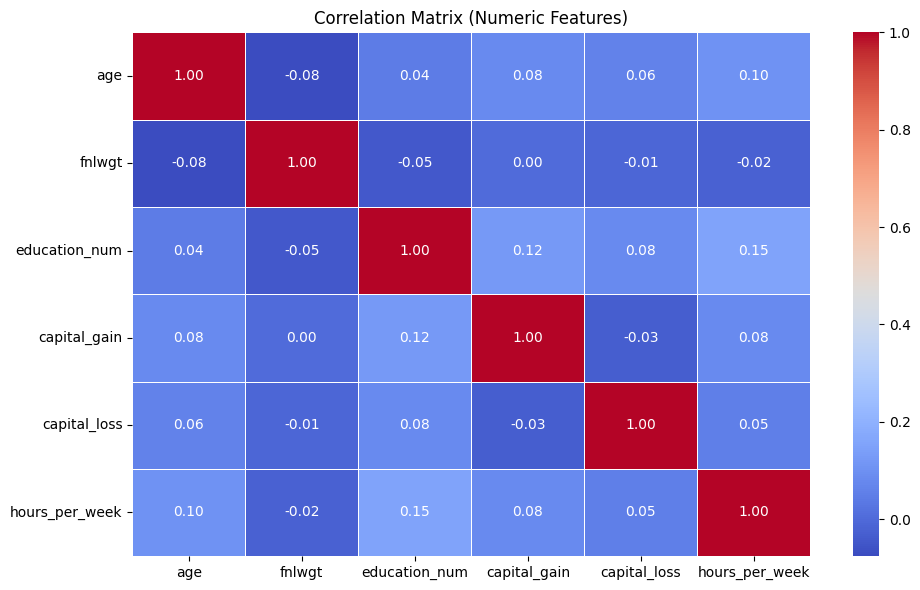

In [17]:

import seaborn as sns

# Select only numerical columns and compute correlation
corr = df.select_dtypes(include=np.number).corr()

# Display table also
display(corr)

# Plot heatmap with annotation values
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,        # <-- shows numbers inside boxes
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # color style
    linewidths=0.5
)

plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()



In [18]:
# ----------------
# CELL 9: Simple outlier check (IQR) for key numeric columns (optional)
# ----------------
# This doesn't remove outliers automatically; it just reports counts.

def iqr_outlier_counts(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return ((series < low) | (series > high)).sum(), low, high

for col in ["age", "hours_per_week", "capital_gain", "capital_loss"]:
    cnt, low, high = iqr_outlier_counts(df[col])
    print(f"{col}: outliers={cnt}, IQR_low={low:.2f}, IQR_high={high:.2f}")


age: outliers=168, IQR_low=-0.50, IQR_high=75.50
hours_per_week: outliers=7947, IQR_low=32.50, IQR_high=52.50
capital_gain: outliers=2538, IQR_low=0.00, IQR_high=0.00
capital_loss: outliers=1427, IQR_low=0.00, IQR_high=0.00


In [19]:
# ----------------
# TRAIN-TEST SPLIT + ENCODING + SCALING
# ----------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1) Separate features (X) and target (y)
X = df.drop("income", axis=1)
y = df["income"]

# Convert target to 0/1 using LabelEncoder
le_y = LabelEncoder()
y = le_y.fit_transform(y)   # <=50K -> 0, >50K -> 1 (usually)

print("Target mapping:", dict(zip(le_y.classes_, le_y.transform(le_y.classes_))))

Target mapping: {'<=50K': np.int64(0), '>50K': np.int64(1)}


In [20]:
# 2) Encode categorical input columns using LabelEncoder (column-wise)
# NOTE: LabelEncoder on features is OK for simple models, but OneHotEncoder is usually better.
cat_cols = X.select_dtypes(include="object").columns
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le   # store encoders if you need inverse_transform later

print("Encoded categorical columns:", list(cat_cols))

Encoded categorical columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


In [21]:
# 3) Train-test split (stratify keeps income class ratio same in train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (24111, 14) X_test: (6028, 14)
y_train: (24111,) y_test: (6028,)


In [22]:
# 4) Standard Scaling (fit only on train, transform both)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled shapes:", X_train_scaled.shape, X_test_scaled.shape)

Scaled shapes: (24111, 14) (6028, 14)


In [23]:
from imblearn.over_sampling import SMOTE

# SMOTE should be applied ONLY on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", X_train_scaled.shape, pd.Series(y_train).value_counts().to_dict())
print("After SMOTE :", X_train_smote.shape, pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: (24111, 14) {0: 18106, 1: 6005}
After SMOTE : (36212, 14) {0: 18106, 1: 18106}


In [24]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight=None,   # SMOTE already balances
    random_state=42
)

svm_model.fit(X_train_smote, y_train_smote)

svm_pred = svm_model.predict(X_test_scaled)

print("=== SVM Confusion Matrix ===")
print(confusion_matrix(y_test, svm_pred))
print("\n=== SVM Classification Report ===")
print(classification_report(y_test, svm_pred, target_names=le_y.classes_))

=== SVM Confusion Matrix ===
[[3526 1001]
 [ 221 1280]]

=== SVM Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      4527
        >50K       0.56      0.85      0.68      1501

    accuracy                           0.80      6028
   macro avg       0.75      0.82      0.76      6028
weighted avg       0.85      0.80      0.81      6028



In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# SMOTE on raw training features (not scaled)
smote_rf = SMOTE(random_state=42)
X_train_rf_smote, y_train_rf_smote = smote_rf.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf_smote, y_train_rf_smote)

rf_pred = rf_model.predict(X_test)

print("=== Random Forest Confusion Matrix ===")
print(confusion_matrix(y_test, rf_pred))
print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, rf_pred, target_names=le_y.classes_))

=== Random Forest Confusion Matrix ===
[[4034  493]
 [ 456 1045]]

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.90      0.89      0.89      4527
        >50K       0.68      0.70      0.69      1501

    accuracy                           0.84      6028
   macro avg       0.79      0.79      0.79      6028
weighted avg       0.84      0.84      0.84      6028



In [26]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

nb_model = GaussianNB()

# Train on scaled + SMOTE data (same as SVM & Logistic Regression)
nb_model.fit(X_train_smote, y_train_smote)

# Predict on scaled test data
nb_pred = nb_model.predict(X_test_scaled)

print("=== Naive Bayes Confusion Matrix ===")
print(confusion_matrix(y_test, nb_pred))
print("\n=== Naive Bayes Classification Report ===")
print(classification_report(y_test, nb_pred, target_names=le_y.classes_))

=== Naive Bayes Confusion Matrix ===
[[4202  325]
 [ 760  741]]

=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89      4527
        >50K       0.70      0.49      0.58      1501

    accuracy                           0.82      6028
   macro avg       0.77      0.71      0.73      6028
weighted avg       0.81      0.82      0.81      6028



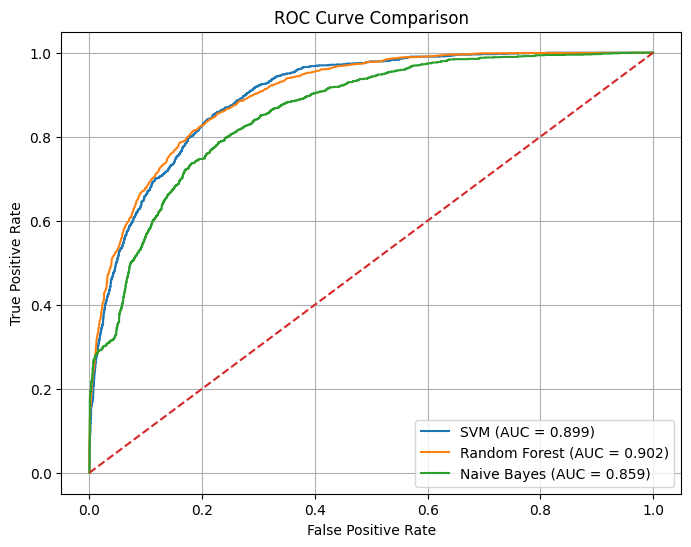

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Scores / probabilities
svm_score = svm_model.decision_function(X_test_scaled)
rf_score = rf_model.predict_proba(X_test)[:, 1]
nb_score = nb_model.predict_proba(X_test_scaled)[:, 1]

# ROC data
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_score)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_score)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_score)

# AUC
auc_svm = auc(fpr_svm, tpr_svm)
auc_rf = auc(fpr_rf, tpr_rf)
auc_nb = auc(fpr_nb, tpr_nb)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

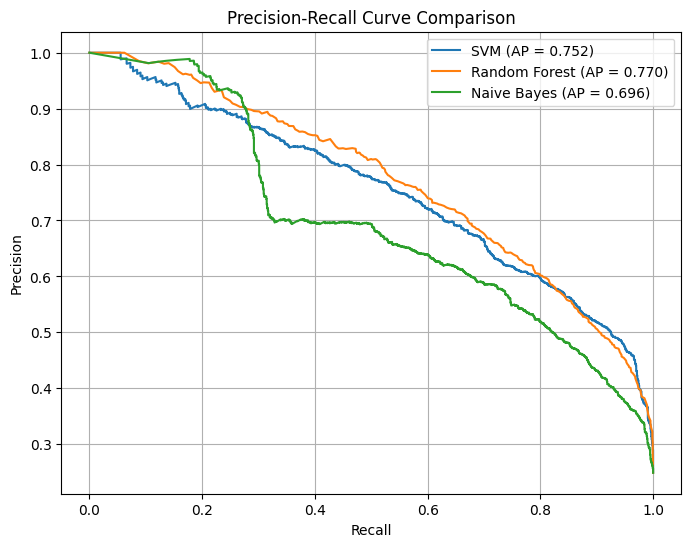

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# PR data
precision_svm, recall_svm, _ = precision_recall_curve(y_test, svm_score)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_score)
precision_nb, recall_nb, _ = precision_recall_curve(y_test, nb_score)

# Average precision
ap_svm = average_precision_score(y_test, svm_score)
ap_rf = average_precision_score(y_test, rf_score)
ap_nb = average_precision_score(y_test, nb_score)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall_svm, precision_svm, label=f"SVM (AP = {ap_svm:.3f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP = {ap_rf:.3f})")
plt.plot(recall_nb, precision_nb, label=f"Naive Bayes (AP = {ap_nb:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

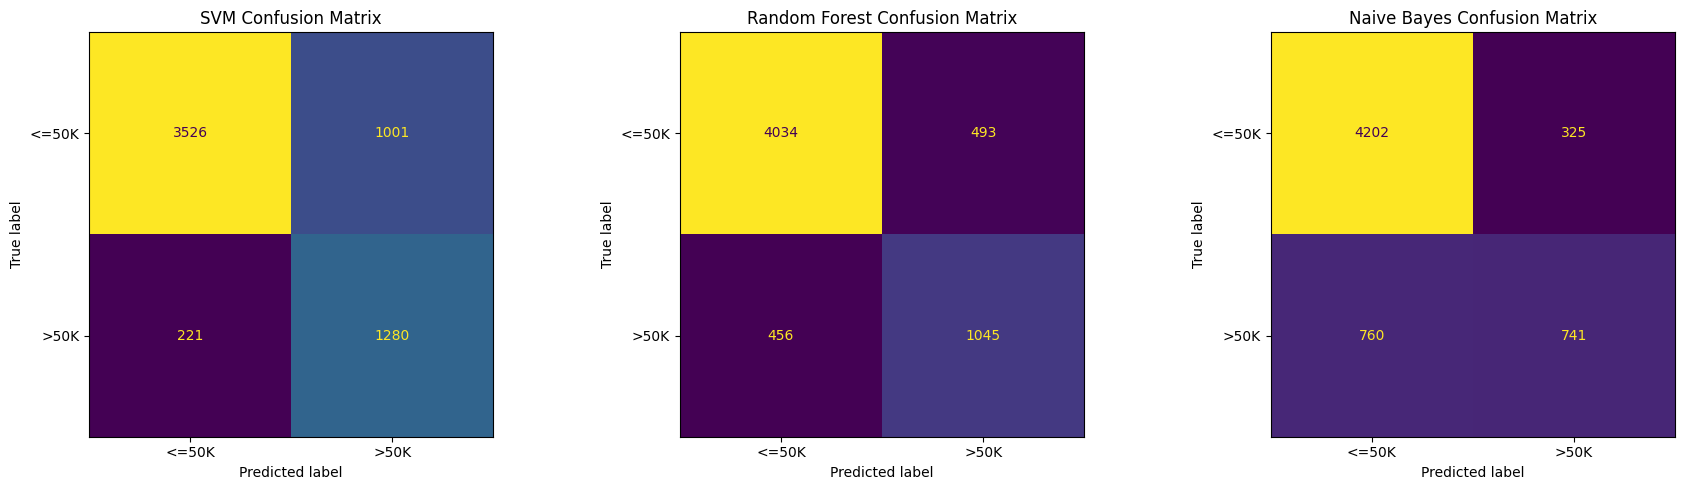

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SVM
cm_svm = confusion_matrix(y_test, svm_model.predict(X_test_scaled))
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le_y.classes_)
disp_svm.plot(ax=axes[0], colorbar=False)
axes[0].set_title("SVM Confusion Matrix")

# Random Forest
cm_rf = confusion_matrix(y_test, rf_model.predict(X_test))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le_y.classes_)
disp_rf.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest Confusion Matrix")

# Naive Bayes
cm_nb = confusion_matrix(y_test, nb_model.predict(X_test_scaled))
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le_y.classes_)
disp_nb.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Naive Bayes Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Define parameter distribution
rf_param_dist = {
    "n_estimators": randint(100, 500),      # Number of trees
    "max_depth": [None, 10, 20, 30, 40],    # Depth of trees
    "min_samples_split": randint(2, 10),    # Minimum samples to split node
    "min_samples_leaf": randint(1, 5),      # Minimum samples at leaf
    "max_features": ["sqrt", "log2", None], # Features per split
    "bootstrap": [True, False]              # Sampling method
}

# RandomizedSearchCV setup
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="f1",        # Focus on minority class
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE-balanced raw data
rf_random.fit(X_train_rf_smote, y_train_rf_smote)

# Best parameters
print("Best RF Parameters:", rf_random.best_params_)

# Best model
best_rf = rf_random.best_estimator_

# Predictions
rf_tuned_pred = best_rf.predict(X_test)

# Evaluation
print("\n=== Tuned Random Forest Results ===")
print(confusion_matrix(y_test, rf_tuned_pred))
print(classification_report(y_test, rf_tuned_pred, target_names=le_y.classes_))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Define parameter range
nb_param_dist = {
    "var_smoothing": np.logspace(-12, -6, 100)  # Controls variance smoothing
}

# RandomizedSearchCV setup
nb_random = RandomizedSearchCV(
    estimator=GaussianNB(),           # Base model
    param_distributions=nb_param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE-balanced scaled data
nb_random.fit(X_train_smote, y_train_smote)

# Best parameters
print("Best NB Parameters:", nb_random.best_params_)

# Best model
best_nb = nb_random.best_estimator_

# Predictions
nb_tuned_pred = best_nb.predict(X_test_scaled)

# Evaluation
print("\n=== Tuned Naive Bayes Results ===")
print(confusion_matrix(y_test, nb_tuned_pred))
print(classification_report(y_test, nb_tuned_pred, target_names=le_y.classes_))

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Simple parameter grid
svm_param_dist = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"]   # only rbf to reduce time
}

# Faster RandomizedSearchCV
svm_random = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=svm_param_dist,
    n_iter=5,          # smaller search
    scoring="f1",
    cv=3,              # fewer folds
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Train
svm_random.fit(X_train_smote, y_train_smote)

# Best model
best_svm = svm_random.best_estimator_

# Prediction
svm_tuned_pred = best_svm.predict(X_test_scaled)

# Results
print("Best SVM Parameters:", svm_random.best_params_)
print("\n=== Tuned SVM Confusion Matrix ===")
print(confusion_matrix(y_test, svm_tuned_pred))
print("\n=== Tuned SVM Classification Report ===")
print(classification_report(y_test, svm_tuned_pred, target_names=le_y.classes_))